# Pipeline

Load JSON files <br>
        ↓<br>
Extract claims<br>
        ↓<br>
Clean text<br>
        ↓<br>
Remove stopwords<br>
        ↓<br>
Bag of Words<br>
        ↓<br>
TF-IDF<br>
        ↓<br>
LDA Topic Modeling<br>
        ↓<br>
NMF Topic Modeling<br>
        ↓<br>
Visualize results<br>

# Imports

In [10]:
import json
import re
import pandas as pd
import numpy as np

from collections import Counter

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF

import matplotlib.pyplot as plt

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


# Paths

In [11]:
TRAIN_JSON = r"/kaggle/input/datasets/d202511054/clef-2026-checkthat-task-2-data/train.json"
VAL_JSON   = r"/kaggle/input/datasets/d202511054/clef-2026-checkthat-task-2-data/validation.json"
TEST_JSON  = r"/kaggle/input/datasets/d202511054/clef-2026-checkthat-task-2-data/test.json"

# Load JSON

In [12]:
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

train = load_json(TRAIN_JSON)
val = load_json(VAL_JSON)
test = load_json(TEST_JSON)

print("Train:", len(train))
print("Validation:", len(val))
print("Test:", len(test))

Train: 6400
Validation: 1600
Test: 2558


# Extract Claims

In [13]:
train_claims = [x["claim"] for x in train]
val_claims   = [x["claim"] for x in val]
test_claims  = [x["claim"] for x in test]

all_claims = train_claims + val_claims + test_claims

print("Total claims:", len(all_claims))

Total claims: 10558


# Cleaning

In [14]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z ]", " ", text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(w)
        for w in words
        if w not in stop_words and len(w) > 2
    ]

    return " ".join(words)

clean_claims = [clean_text(c) for c in all_claims]

# Bag of Words

In [15]:
bow_vectorizer = CountVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

bow = bow_vectorizer.fit_transform(clean_claims)

print(bow.shape)

(10558, 5000)


# Most Frequent Words

In [16]:
word_freq = np.asarray(bow.sum(axis=0)).flatten()

words = bow_vectorizer.get_feature_names_out()

freq_df = pd.DataFrame({
    "Word": words,
    "Frequency": word_freq
})

freq_df = freq_df.sort_values(
    by="Frequency",
    ascending=False
)

freq_df.head(50)

,Word,Frequency
4027,show,1460
4953,year,1408
3362,president,1047
4730,video,1022
3841,say,1019
4578,trump,855
2685,million,836
3169,people,761
3004,one,652
4221,state,641


# Plot Top 30 Words

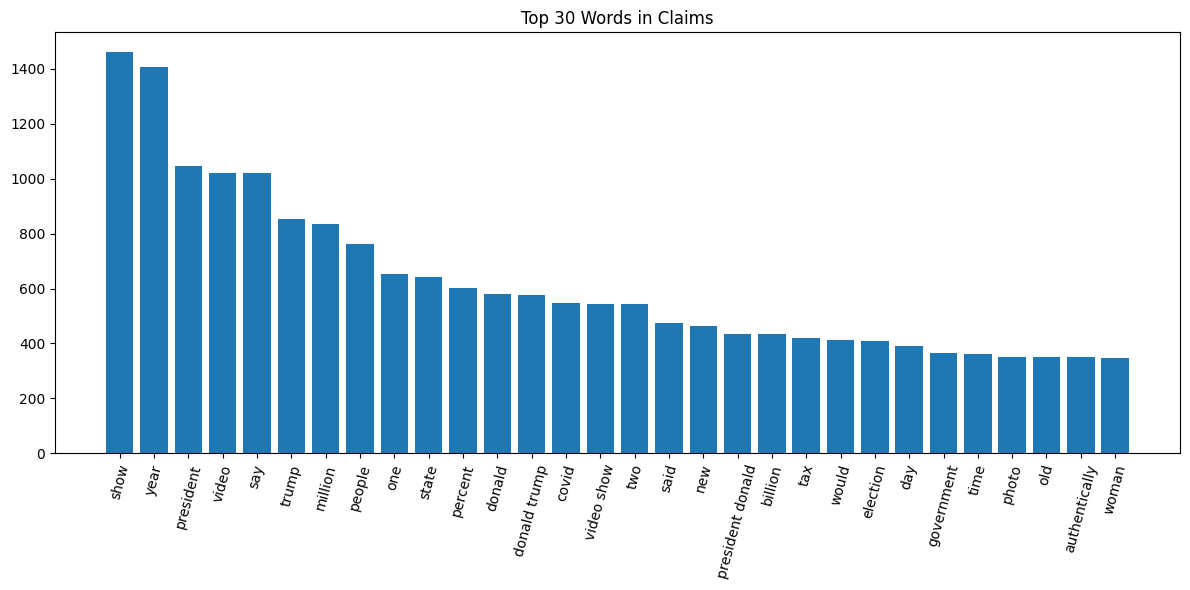

In [17]:
top = freq_df.head(30)

plt.figure(figsize=(12,6))
plt.bar(top["Word"], top["Frequency"])
plt.xticks(rotation=75)
plt.title("Top 30 Words in Claims")
plt.tight_layout()
plt.show()

# TF-IDF

In [18]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

tfidf = tfidf_vectorizer.fit_transform(clean_claims)

print(tfidf.shape)

(10558, 5000)


# LDA Topic Modeling

In [19]:
NUM_TOPICS = 10

lda = LatentDirichletAllocation(
    n_components=NUM_TOPICS,
    random_state=42,
    learning_method="batch"
)

lda.fit(bow)

LatentDirichletAllocation(random_state=42)

# Print LDA Topics

In [20]:
feature_names = bow_vectorizer.get_feature_names_out()

for idx, topic in enumerate(lda.components_):

    top_words = [feature_names[i]
                 for i in topic.argsort()[-10:][::-1]]

    print(f"\nTopic {idx+1}")
    print(", ".join(top_words))


Topic 1
people, covid, million, tax, american, coronavirus, new, obama, percent, vaccine

Topic 2
year, say, million, billion, state, job, percent, tax, year old, old

Topic 3
trump, president, show, epstein, photograph, donald trump, donald, jeffrey, jeffrey epstein, vaccine

Topic 4
percent, year, say, health, care, one, health care, country, found, state

Topic 5
authentically, video, showed, shared, authentically showed, online, show, january, enforcement, agent

Topic 6
house, white, one, police, new, said, white house, december, september, world

Topic 7
show, video, video show, photo, photo show, image, viral, indian, india, two

Topic 8
trump, president, donald, donald trump, president donald, election, vote, said, new, presidential

Topic 9
said, day, president, biden, state, united, joe, joe biden, party, court

Topic 10
year, school, people, woman, two, covid, men, vaccine, every, say


# NMF Topic Modeling

In [21]:
nmf = NMF(
    n_components=10,
    random_state=42
)

nmf.fit(tfidf)

NMF(n_components=10, random_state=42)

# Print NMF Topics

In [22]:
feature_names = tfidf_vectorizer.get_feature_names_out()

for idx, topic in enumerate(nmf.components_):

    top_words = [feature_names[i]
                 for i in topic.argsort()[-10:][::-1]]

    print(f"\nTopic {idx+1}")
    print(", ".join(top_words))


Topic 1
trump, donald, donald trump, president, president donald, said, house, white house, trump said, white

Topic 2
video, video show, show, viral video, viral, india, pakistan, two, protest, september

Topic 3
say, percent, tax, state, billion, one, job, new, health, pay

Topic 4
year, old, year old, girl, old girl, man, last, show year, last year, boy

Topic 5
covid, vaccine, covid vaccine, death, people, pfizer, child, died, cdc, day

Topic 6
photo, photo show, show, killed, woman, photograph, photograph show, image, image show, two

Topic 7
authentically, showed, authentically showed, image, online, shared, january, authentically show, epstein, shared online

Topic 8
million, people, million people, american, job, country, million american, number, million job, work

Topic 9
election, vote, voter, ballot, presidential, bihar, presidential election, assembly, assembly election, state

Topic 10
obama, president, biden, barack, barack obama, joe, joe biden, president barack, forme

# Dominant Topic for Every Claim

In [23]:
topic_scores = lda.transform(bow)

dominant_topics = np.argmax(topic_scores, axis=1)

topic_df = pd.DataFrame({
    "Claim": all_claims,
    "Topic": dominant_topics
})

topic_df.head()

,Claim,Topic
0,“The first randomized controlled trial of more...,0
1,Says the United States has the highest incarce...,1
2,Six masks worn to school by children were sent...,9
3,"Judge Amy Coney Barrett, who was nominated to ...",8
4,"""What has happened since 2005? We’ve seen viol...",1


# Topic Distribution

In [24]:
topic_counts = Counter(dominant_topics)

topic_counts = pd.DataFrame({
    "Topic": list(topic_counts.keys()),
    "Count": list(topic_counts.values())
})

topic_counts = topic_counts.sort_values("Topic")

topic_counts

,Topic,Count
0,0,988
1,1,2362
6,2,722
7,3,981
5,4,695
8,5,661
4,6,1580
9,7,893
3,8,692
2,9,984


# Plot Topic Distribution

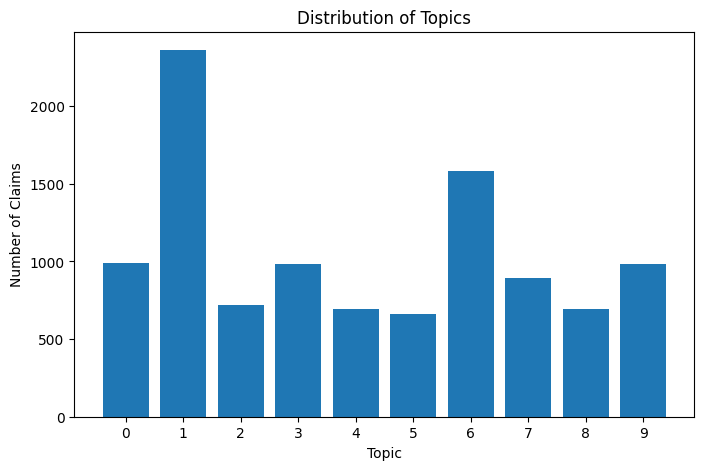

In [25]:
plt.figure(figsize=(8,5))

plt.bar(
    topic_counts["Topic"].astype(str),
    topic_counts["Count"]
)

plt.xlabel("Topic")
plt.ylabel("Number of Claims")
plt.title("Distribution of Topics")

plt.show()

# 2. Analysis


# Clean Claims and Keep Labels

In [26]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z ]", " ", text)

    words = []

    for w in text.split():

        if len(w) < 3:
            continue

        if w in stop_words:
            continue

        words.append(lemmatizer.lemmatize(w))

    return " ".join(words)


def build_dataframe(dataset, label_key):

    claims = []
    labels = []

    for item in dataset:

        claims.append(clean_text(item["claim"]))
        labels.append(item[label_key])

    return pd.DataFrame({
        "claim": claims,
        "label": labels
    })


train_df = build_dataframe(train, "label")
val_df   = build_dataframe(val, "label")
test_df  = build_dataframe(test, "Label")

all_df = pd.concat(
    [train_df, val_df, test_df],
    ignore_index=True
)

all_df.head()

,claim,label
0,first randomized controlled trial individual a...,Conflicting
1,say united state highest incarceration rate wo...,Conflicting
2,six mask worn school child sent university flo...,Conflicting
3,judge amy coney barrett nominated supreme cour...,Conflicting
4,happened since seen violent crime continuously...,Conflicting


# Word Frequency per Label

In [27]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    max_features=10000,
    ngram_range=(1,1)
)

vectorizer.fit(all_df.claim)

vocab = vectorizer.get_feature_names_out()

for label in sorted(all_df.label.unique()):

    subset = all_df[all_df.label == label]

    X = vectorizer.transform(subset.claim)

    freq = X.sum(axis=0).A1

    df = pd.DataFrame({
        "word": vocab,
        "count": freq
    })

    df = df.sort_values(
        "count",
        ascending=False
    )

    print("\n")
    print("="*80)
    print(label)
    print("="*80)

    display(df.head(30))



Conflicting


,word,count
9921,year,365
8201,say,359
8430,show,232
6968,percent,230
5674,million,222
8734,state,187
6961,people,186
9044,tax,184
837,billion,171
7381,president,171




False


,word,count
8430,show,1128
9611,video,800
9921,year,693
7381,president,556
9353,trump,468
6961,people,434
5674,million,425
2004,covid,421
8201,say,415
9390,two,359




True


,word,count
9921,year,350
7381,president,320
9353,trump,280
8201,say,245
6968,percent,242
2787,donald,228
8734,state,190
5674,million,189
6532,one,152
6961,people,141


# TF-IDF Words per Label

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

for label in sorted(all_df.label.unique()):

    subset = all_df[all_df.label == label]

    tfidf = TfidfVectorizer(
        max_features=5000
    )

    X = tfidf.fit_transform(subset.claim)

    scores = X.mean(axis=0).A1

    words = tfidf.get_feature_names_out()

    df = pd.DataFrame({
        "word": words,
        "score": scores
    })

    df = df.sort_values(
        "score",
        ascending=False
    )

    print("\n")
    print("="*80)
    print(label)
    print("="*80)

    display(df.head(30))



Conflicting


,word,score
4250,say,0.024784
4964,year,0.023993
3457,percent,0.018151
2920,million,0.017687
4405,show,0.017525
3453,people,0.015578
306,billion,0.015440
4617,tax,0.015385
4516,state,0.014936
3639,president,0.013391




False


,word,score
4182,show,0.026053
4786,video,0.020772
4958,year,0.017840
3410,president,0.013935
3200,people,0.012820
4665,trump,0.012728
907,covid,0.012692
4043,say,0.012572
2814,million,0.011907
4688,two,0.010996




True


,word,score
4977,year,0.024432
3537,president,0.021218
4072,say,0.020608
3356,percent,0.020133
4771,trump,0.018807
2889,million,0.016458
1230,donald,0.016052
4405,state,0.015271
3180,one,0.012975
3352,people,0.012642


# Most Discriminative Words (Chi-Square)

In [29]:
from sklearn.feature_selection import chi2

vectorizer = CountVectorizer(
    max_features=10000
)

X = vectorizer.fit_transform(all_df.claim)

y = all_df.label

scores, pvalues = chi2(X, y)

words = vectorizer.get_feature_names_out()

chi_df = pd.DataFrame({

    "word": words,
    "chi2": scores

})

chi_df = chi_df.sort_values(
    "chi2",
    ascending=False
)

chi_df.head(100)

,word,chi2
6968,percent,388.421266
9044,tax,196.848467
8201,say,192.626377
8430,show,192.331109
2787,donald,160.273626
...,...,...
4018,hindu,28.512142
3512,former,28.406033
8483,singer,28.166387
3757,governor,28.012815


# Top Words for Each Label using Chi-Square

In [30]:
labels = sorted(all_df.label.unique())

for label in labels:

    y_binary = (all_df.label == label)

    scores, _ = chi2(X, y_binary)

    df = pd.DataFrame({

        "word": words,
        "score": scores

    })

    df = df.sort_values(
        "score",
        ascending=False
    )

    print("\n")
    print("="*80)
    print(label)
    print("="*80)

    display(df.head(30))



Conflicting


,word,score
9044,tax,142.099390
8201,say,139.785062
6968,percent,118.198265
837,billion,98.217668
4505,job,91.758401
5497,medicare,57.358128
6426,obamacare,55.467072
302,american,44.993429
4328,insurance,43.499253
3952,health,42.254637




False


,word,score
6968,percent,384.927966
9044,tax,175.451289
8201,say,171.174806
8430,show,167.081986
9611,video,131.810417
8734,state,102.790325
7883,republican,87.182166
4505,job,84.648073
8478,since,83.099804
837,billion,81.984615




True


,word,score
6968,percent,176.555848
2787,donald,156.902164
8430,show,138.904337
9611,video,106.910242
9353,trump,106.315636
7381,president,92.264356
3087,epstein,76.633822
4477,jeffrey,71.339339
2484,department,67.157981
7883,republican,62.593918


# Word Cloud

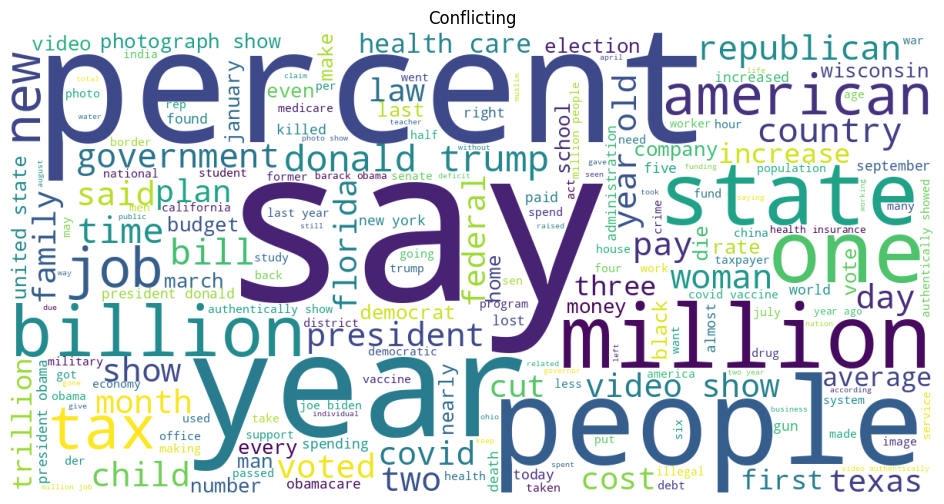

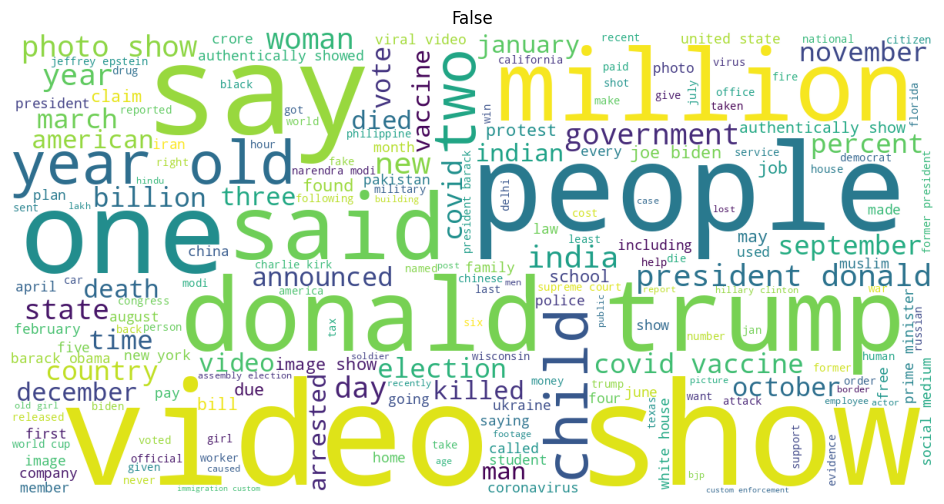

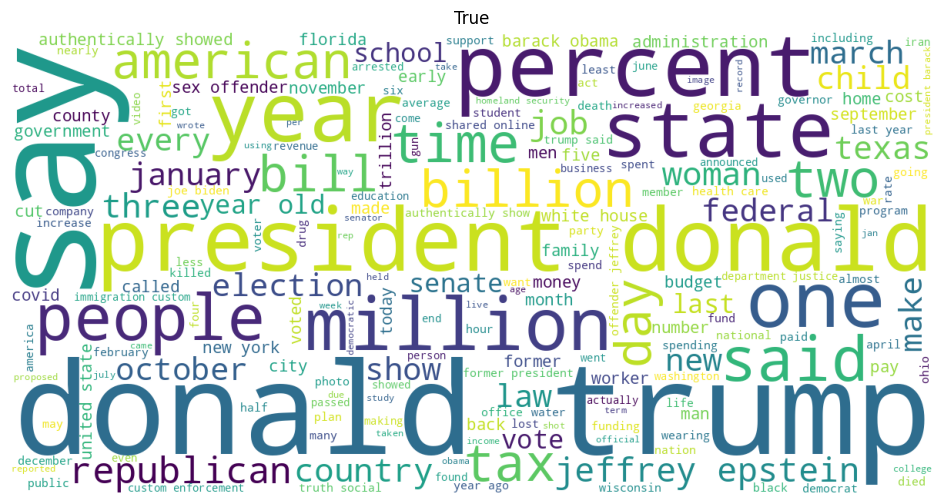

In [31]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for label in sorted(all_df.label.unique()):

    text = " ".join(
        all_df.loc[
            all_df.label==label,
            "claim"
        ]
    )

    wc = WordCloud(
        width=1200,
        height=600,
        background_color="white"
    ).generate(text)

    plt.figure(figsize=(14,6))
    plt.imshow(wc)
    plt.axis("off")
    plt.title(label)
    plt.show()

# 2. Analysis 

# Compare Train / Validation / Test
This tells whether the vocabulary shifts across splits.

In [32]:
def top_words(df, topk=30):

    cv = CountVectorizer(max_features=10000)

    X = cv.fit_transform(df.claim)

    freq = X.sum(axis=0).A1

    words = cv.get_feature_names_out()

    result = pd.DataFrame({

        "word": words,
        "count": freq

    })

    return result.sort_values(
        "count",
        ascending=False
    ).head(topk)


print("TRAIN")
display(top_words(train_df))

print("VALIDATION")
display(top_words(val_df))

print("TEST")
display(top_words(test_df))

TRAIN


,word,count
9933,year,946
8300,say,780
8616,show,689
6853,people,522
5835,million,519
6860,percent,477
6515,one,448
2083,covid,431
9043,state,420
7215,president,419


VALIDATION


,word,count
5375,year,247
4246,say,222
4403,show,167
3087,million,121
3556,percent,120
3553,people,117
1107,covid,114
3727,president,113
3391,one,112
4585,state,111


TEST


,word,count
4527,show,604
5327,video,530
3786,president,515
5149,trump,460
1502,donald,379
358,authentically,326
5539,year,215
3119,million,196
4324,said,194
2357,image,187


# Build Vocabulary

In [34]:
vectorizer = CountVectorizer(
    max_features=20000,
    min_df=2,
    ngram_range=(1,1)
)

X = vectorizer.fit_transform(all_df["claim"])

vocab = np.array(vectorizer.get_feature_names_out())

print("Vocabulary Size:", len(vocab))

Vocabulary Size: 8239


# Function to Compute Log-Odds Ratio

In [36]:
def log_odds_ratio(
    X,
    labels,
    target_label,
    vocab,
    alpha=0.01
):
    """
    Monroe et al. (2008)
    Log-Odds Ratio with Informative Dirichlet Prior
    """

    target_mask = labels == target_label
    other_mask = labels != target_label

    target_counts = np.asarray(
        X[target_mask].sum(axis=0)
    ).flatten()

    other_counts = np.asarray(
        X[other_mask].sum(axis=0)
    ).flatten()

    target_counts = target_counts + alpha
    other_counts = other_counts + alpha

    target_total = target_counts.sum()
    other_total = other_counts.sum()

    log_odds = np.log(
        target_counts /
        (target_total - target_counts)
    ) - np.log(
        other_counts /
        (other_total - other_counts)
    )

    variance = (
        1/target_counts +
        1/other_counts
    )

    z_score = log_odds / np.sqrt(variance)

    df = pd.DataFrame({

        "word": vocab,

        "target_count": target_counts,

        "other_count": other_counts,

        "log_odds": log_odds,

        "z_score": z_score

    })

    return df.sort_values(
        "z_score",
        ascending=False
    )

# Top Words for Every Label

In [37]:
labels = all_df["label"].values

for label in sorted(all_df["label"].unique()):

    print("="*80)
    print(label)
    print("="*80)

    result = log_odds_ratio(
        X,
        labels,
        label,
        vocab
    )

    display(result.head(40))

Conflicting


,word,target_count,other_count,log_odds,z_score
6485,say,359.01,660.01,0.724149,11.042449
7319,tax,184.01,237.01,1.077462,10.966158
5408,percent,230.01,373.01,0.847484,10.108797
795,billion,171.01,262.01,0.903148,9.187020
3899,job,134.01,186.01,1.001264,8.836838
4598,medicare,35.01,23.01,1.746685,6.508489
5085,obamacare,33.01,21.01,1.778735,6.373381
270,american,115.01,211.01,0.721266,6.222899
3354,health,87.01,145.01,0.816964,6.024539
2748,federal,73.01,112.01,0.899548,5.980459


False


,word,target_count,other_count,log_odds,z_score
6711,show,1128.01,332.01,0.891505,14.278304
7877,video,800.01,222.01,0.947900,12.495875
1723,covid,421.01,127.01,0.860935,8.504273
7808,vaccine,258.01,59.01,1.136889,7.878725
5458,photo,280.01,72.01,1.019671,7.717196
3644,india,224.01,48.01,1.201620,7.555554
3570,image,268.01,78.01,0.895553,6.961313
4710,minister,123.01,15.01,1.764125,6.452364
4764,modi,119.01,13.01,1.874049,6.417877
3645,indian,145.01,28.01,1.304869,6.322290


True


,word,target_count,other_count,log_odds,z_score
5408,percent,242.01,361.01,0.952530,11.465393
2210,donald,228.01,352.01,0.917722,10.795535
7626,trump,280.01,575.01,0.632203,8.675471
5675,president,320.01,727.01,0.531204,7.918369
2506,epstein,74.01,87.01,1.186788,7.505214
3872,jeffrey,61.01,65.01,1.284820,7.207971
1989,department,69.01,85.01,1.139916,7.035184
6174,republican,79.01,112.01,0.999538,6.803454
6639,sex,54.01,71.01,1.074334,5.950402
6758,since,89.01,160.01,0.761967,5.762515


# Plot Top 20 Words

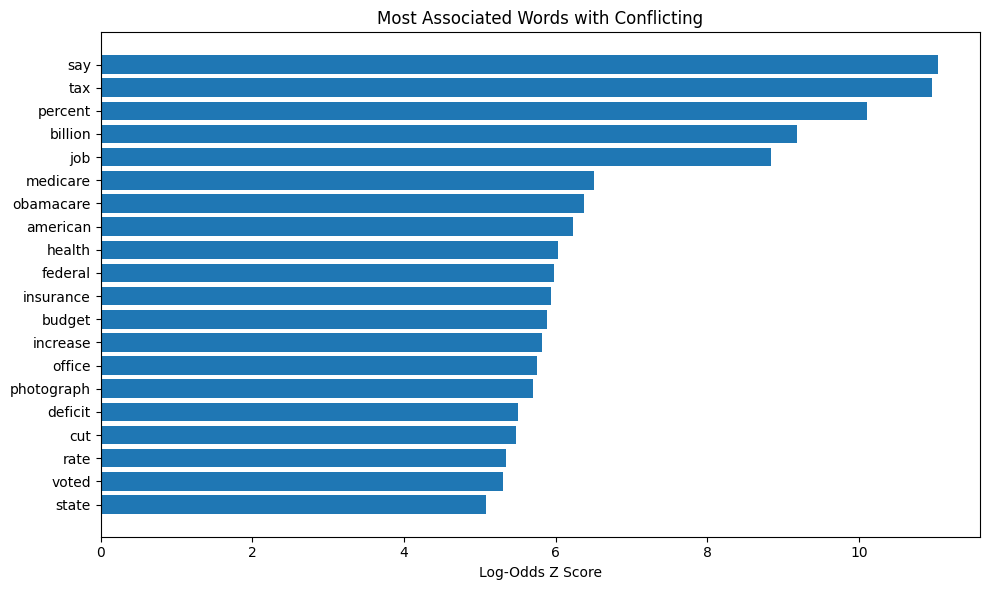

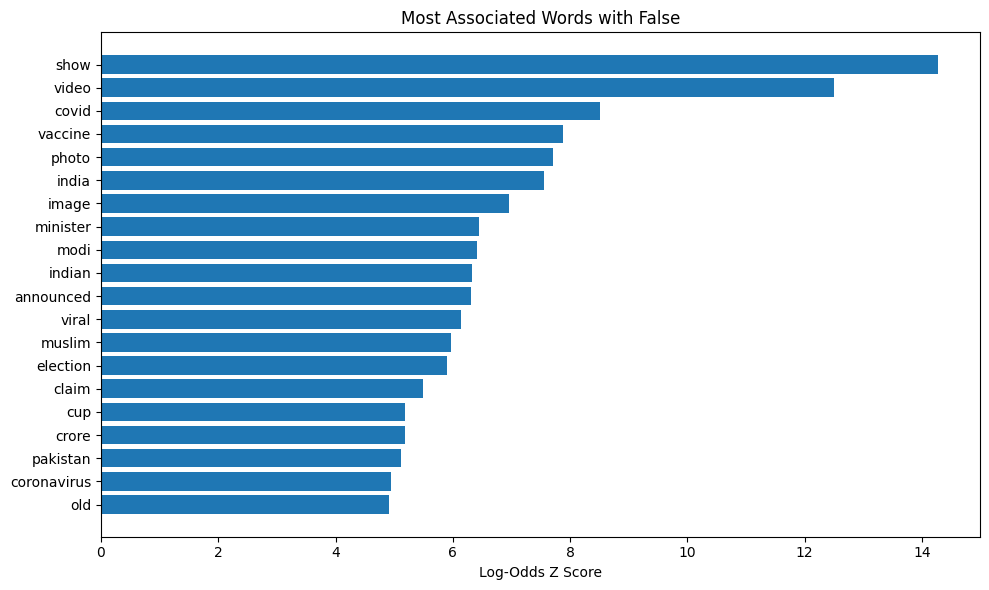

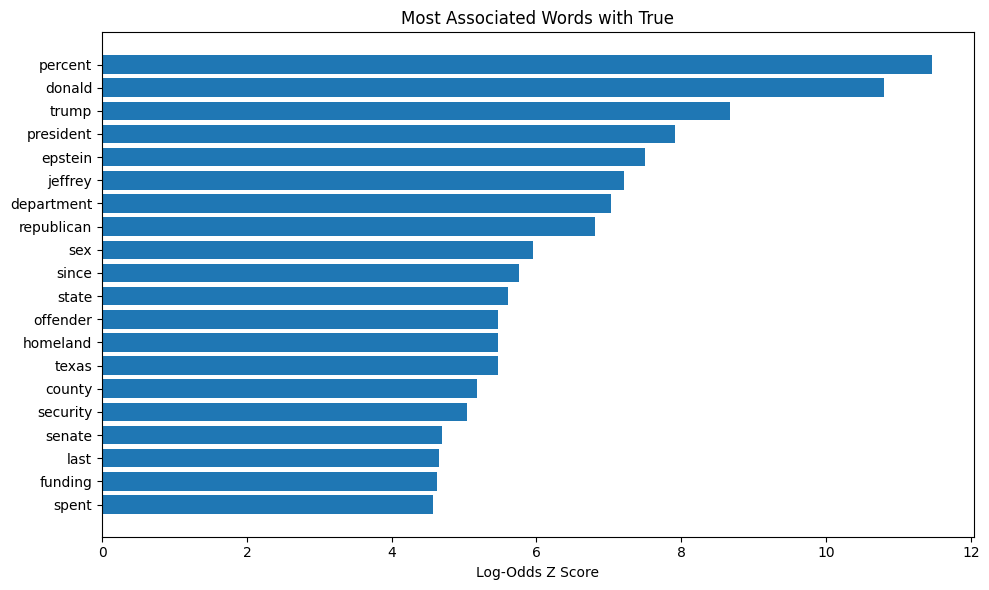

In [38]:
import matplotlib.pyplot as plt

for label in sorted(all_df["label"].unique()):

    result = log_odds_ratio(
        X,
        labels,
        label,
        vocab
    )

    top = result.head(20)

    plt.figure(figsize=(10,6))

    plt.barh(
        top["word"][::-1],
        top["z_score"][::-1]
    )

    plt.title(f"Most Associated Words with {label}")

    plt.xlabel("Log-Odds Z Score")

    plt.tight_layout()

    plt.show()

# Save Results

In [39]:
for label in sorted(all_df["label"].unique()):

    result = log_odds_ratio(
        X,
        labels,
        label,
        vocab
    )

    result.to_csv(
        f"log_odds_{label}.csv",
        index=False
    )

print("Saved.")

Saved.
